In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fastf1
import requests
from scipy.stats import spearmanr

In [2]:
def get_race_results(Result):

    race = Result.results[["Abbreviation","Position"]]
    race.rename(columns={"Abbreviation":"Driver"},inplace=True)

    return race

In [3]:
season = 2026
race = 'Canada'

Result = fastf1.get_session(season, race, 'R')
Result.load()


result = get_race_results(Result)



req         WARNING 	DEFAULT CACHE ENABLED! (12.81 GB) /home/satyam/.cache/fastf1
core           INFO 	Loading data for Canadian Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data

In [4]:
result.reset_index(inplace=True, drop=True)

In [5]:
result

,Driver,Position
0,ANT,1.0
1,HAM,2.0
2,VER,3.0
3,LEC,4.0
4,HAD,5.0
5,COL,6.0
6,LAW,7.0
7,GAS,8.0
8,SAI,9.0
9,BEA,10.0


In [6]:
PRE = pd.read_csv("Data/Predicted1.csv")

In [7]:
PRE

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Average_Laptime(s),Qualifying_Time(s),Starting_Pos,Predicted_Standing,Predicted_Pos
0,RUS,73.544,72.965,74.702,87.752375,72.578,1.0,5.54,1
1,ANT,73.402,73.033,74.380,88.209083,72.646,2.0,5.62,2
2,NOR,74.799,73.280,74.596,89.301583,72.729,3.0,5.92,3
3,PIA,74.963,73.299,74.793,91.068583,72.781,4.0,6.58,4
4,HAM,74.176,73.326,74.695,85.331389,72.868,5.0,8.20,5
5,VER,74.366,73.504,74.974,85.870167,72.907,6.0,8.72,6
6,HAD,76.253,73.605,74.941,88.088857,72.935,7.0,9.28,7
7,LEC,74.355,73.410,74.741,88.173125,72.976,8.0,9.90,8
8,LIN,75.452,73.737,75.653,88.946625,73.280,9.0,11.48,9
9,LAW,77.431,74.536,76.257,88.344860,73.897,12.0,11.98,10


In [8]:
PRE.set_index("Driver", inplace=True)
result.set_index("Driver", inplace=True)

Final = result.copy()
Final["Predicted_Pos"] = PRE["Predicted_Pos"]

PRE.reset_index(inplace=True)
Final.reset_index(inplace=True)
result.reset_index(inplace=True)

In [9]:
Final

,Driver,Position,Predicted_Pos
0,ANT,1.0,2.0
1,HAM,2.0,5.0
2,VER,3.0,6.0
3,LEC,4.0,8.0
4,HAD,5.0,7.0
5,COL,6.0,NaN
6,LAW,7.0,10.0
7,GAS,8.0,12.0
8,SAI,9.0,14.0
9,BEA,10.0,15.0


In [12]:
Final.fillna(22,inplace=True)

In [13]:
Final

,Driver,Position,Predicted_Pos
0,ANT,1.0,2.0
1,HAM,2.0,5.0
2,VER,3.0,6.0
3,LEC,4.0,8.0
4,HAD,5.0,7.0
5,COL,6.0,22.0
6,LAW,7.0,10.0
7,GAS,8.0,12.0
8,SAI,9.0,14.0
9,BEA,10.0,15.0


In [14]:

rho, p_value = spearmanr(Final['Position'],Final['Predicted_Pos'])

In [15]:
print(f"{rho}, {p_value}")

0.30208921513269343, 0.17181616844364883


In [16]:
podium = Final.loc[:,["Driver"]]
print("\n Final Standing")
print(f"🥇P1: {podium.iloc[0]['Driver']}")
print(f"🥈P2: {podium.iloc[1]['Driver']}")
print(f"🥉P3: {podium.iloc[2]['Driver']}")
print(f"P4: {podium.iloc[3]['Driver']}")
print(f"P5: {podium.iloc[4]['Driver']}")
print(f"P6: {podium.iloc[5]['Driver']}")
print(f"P7: {podium.iloc[6]['Driver']}")
print(f"P8: {podium.iloc[7]['Driver']}")
print(f"P9: {podium.iloc[8]['Driver']}")
print(f"P10: {podium.iloc[9]['Driver']}")
print(f"P11: {podium.iloc[10]['Driver']}")
print(f"P12: {podium.iloc[11]['Driver']}")

print(f"Spearman Rank (Final): {rho:.2f}")


 Final Standing
🥇P1: ANT
🥈P2: HAM
🥉P3: VER
P4: LEC
P5: HAD
P6: COL
P7: LAW
P8: GAS
P9: SAI
P10: BEA
P11: PIA
P12: HUL
Spearman Rank (Final): 0.30


In [17]:
PRE.set_index("Driver", inplace=True)
result.set_index("Driver", inplace=True)

df = PRE.copy()
df["Actual_Pos"] = result["Position"]


PRE.reset_index(inplace=True)
Final.reset_index(inplace=True)

df.reset_index("Driver", inplace=True)

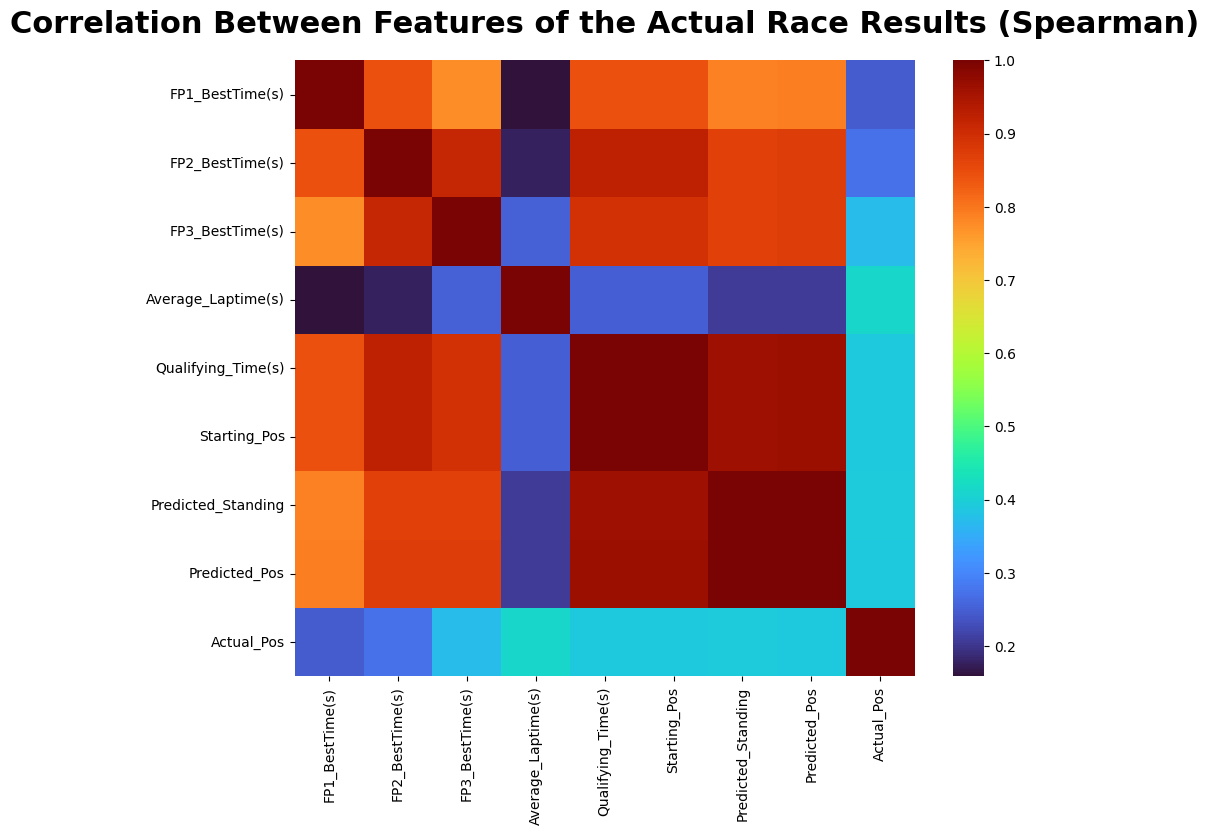

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.iloc[:,1:].corr(method='spearman'), cmap='turbo')

plt.title('Correlation Between Features of the Actual Race Results (Spearman)', fontsize=22, fontweight='bold',pad=20)
plt.savefig('Plots/Result_Correlation_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


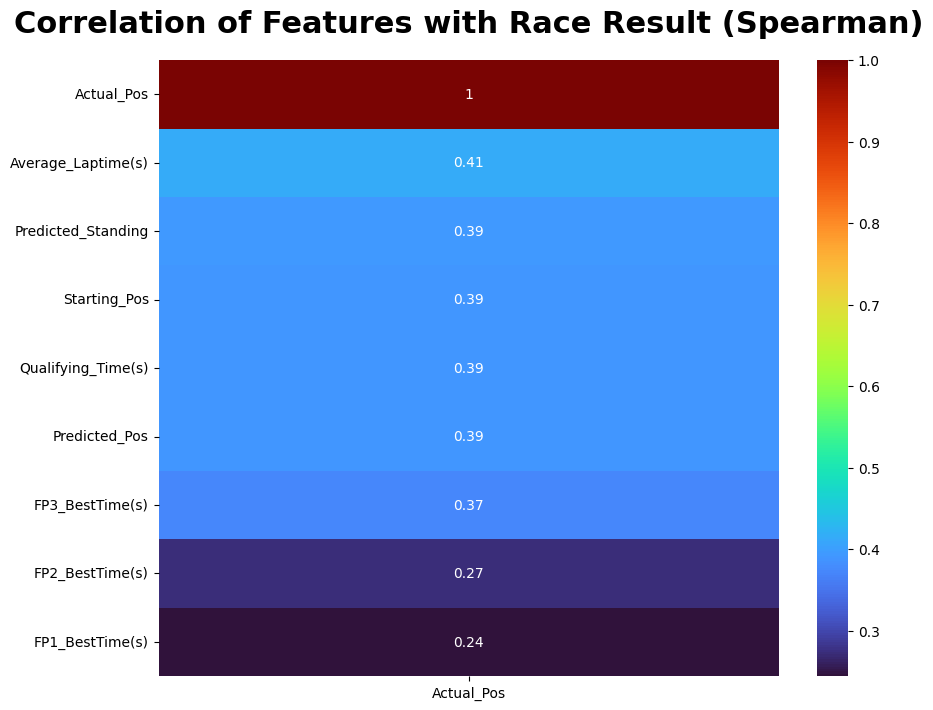

In [19]:
corr = df.iloc[:,1:].corr(method='spearman')[['Actual_Pos']].sort_values(by='Actual_Pos', ascending=False)
plt.figure(figsize=(10,8))
plt.title('Correlation of Features with Race Result (Spearman)', fontsize=22, fontweight='bold',pad=20)
sns.heatmap(corr, annot=True, cmap='turbo')
plt.savefig('Plots/Result_Feature_RaceResult_Correlation.png', dpi=300, bbox_inches='tight')
plt.show()